In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import pandas as pd
import os
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('2307_BSCS009_Shapes_Dataset/shapes_2307BSCS009_labels.csv')
df.head()

print(f'The Total Number Of Images Are: {len(df)}') # total no. of images in data
print(df.value_counts('label_name')) # no. of images by label name/ class name


The Total Number Of Images Are: 375
label_name
circle      75
triangle    75
square      75
diamond     75
pentagon    75
Name: count, dtype: int64


In [3]:

DATASET_DIRECTORY = '2307_BSCS009_Shapes_Dataset'

X = []
y = []

for _, row in df.iterrows():
   # these extra steps are because my labels are capitalized in the dataset
  label_name = row['label_name']
  label_name = label_name.capitalize()

  #reaching Image Path
  img_path = os.path.join(DATASET_DIRECTORY,label_name,row['Filename'])


  #Preprocessing Images
  img = Image.open(img_path).convert('L')
  img = np.array(img) #Converting Images Into Pixels

  X.append(img)
  y.append(row['label'])
#-------------------------For Loop Ends Here-----------------------------------#

In [4]:


X = np.array(X); y = np.array(y) # Making an np array of the X_set whole
X = X / 255.0   # Normalizing Image Pixel Values

print(X.shape)
print(y.shape)


(375, 28, 28)
(375,)


In [5]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=32, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(300, 28, 28) (75, 28, 28) (300,) (75,)


In [6]:

model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation = tf.nn.relu),
    Dense(5, activation = tf.nn.softmax)
])

model.compile(
              optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )


d:\Shapes Classifier\env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:

history = model.fit(X_train, y_train, epochs = 15)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5400 - loss: 1.2703
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9467 - loss: 0.4065
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9933 - loss: 0.1609 
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9967 - loss: 0.0879 
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0597 
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9967 - loss: 0.0448 
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0343 
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0292 
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9967 - loss: 0.0255 
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0220 
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0185 
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy:

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,377 (1.16 MB)

 Trainable params: 101,125 (395.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 202,252 (790.05 KB)

In [9]:
model.save('shapes_classifier_2307-BSCS009.keras')

In [10]:
#Evaluating the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {test_acc*100:.2f}')
print(f'Test Loss: {test_loss*100:.2f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0245  

Test Accuracy: 100.00
Test Loss: 2.45


In [11]:
classifications = model.predict(X_test)
print(classifications[1])
print(y_test[1])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 
[5.6191759e-05 9.9938679e-01 2.8495732e-04 2.7582544e-05 2.4444156e-04]
1


<Figure size 800x600 with 0 Axes>

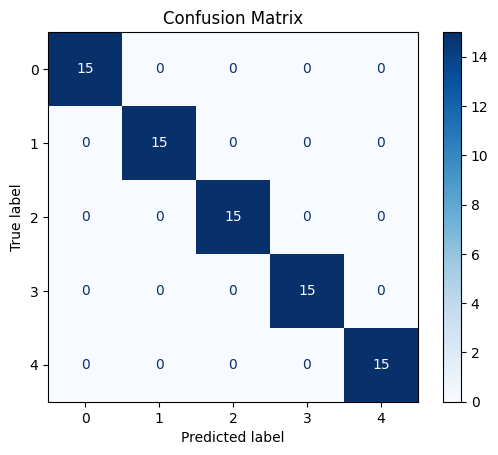

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [ ]:
# Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Get predicted class labels
pred_labels = np.argmax(classifications, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
labels = np.unique(y_test)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score for each class
print(classification_report(y_test, pred_labels, target_names=[str(l) for l in labels]))

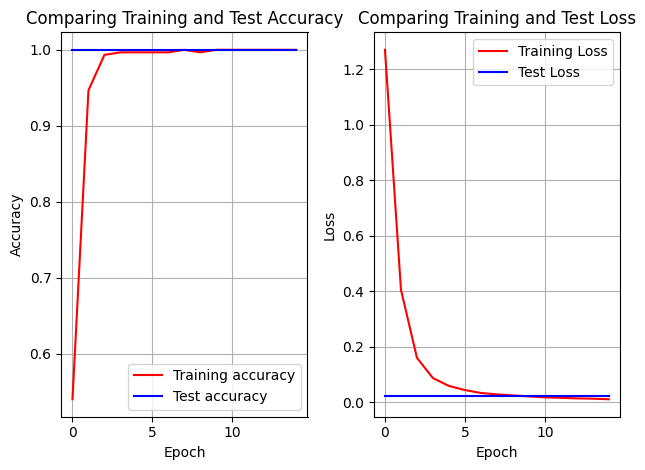

In [13]:

# # Get training loss and accuracy from history
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

# plt.figure(figsize=(12, 5)) # Create a figure with a specific size

# # Subplot 1: Training Accuracy
# plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
# plt.plot(epochs, acc, 'r', label='Training accuracy')
# plt.title('Training Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend(loc=0)
# plt.grid(True)

# # Subplot 2: Training Loss
# plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
# plt.plot(epochs, loss, 'b', label='Training loss')
# plt.title('Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend(loc=0)
# plt.grid(True)

# plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
# plt.show()

# Comparing Training and Test Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, [test_acc]*len(epochs), 'b', label='Test accuracy')
plt.title('Comparing Training and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc=0)
plt.grid(True)
plt.tight_layout()

#Comparision Loss Training and Test
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, [test_loss]*len(epochs), 'b', label='Test Loss')
plt.title('Comparing Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc=0)
plt.grid(True)
plt.tight_layout()


plt.show()
